# File-level AST Statistics — apache/groovy @ BASE_COMMIT

Visualises the outputs of `build_file_ast_graphs.py` and `ingest_base_kg_and_ast.py`:
- `outputs/file_ast_subgraph_stats.csv` — per-file AST metrics
- `outputs/file_ast_neo4j_summary.json` — Neo4j graph-level aggregates

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.15)
plt.rcParams['figure.dpi'] = 120

ROOT   = Path('../../')           # repo root relative to this notebook
OUT    = ROOT / 'outputs'
CSV    = OUT  / 'file_ast_subgraph_stats.csv'
JFILE  = OUT  / 'file_ast_neo4j_summary.json'

df = pd.read_csv(CSV)
summary = json.loads(JFILE.read_text())

print(f'Files: {len(df)}  |  columns: {list(df.columns)}')
df.head(3)

Files: 120  |  columns: ['file', 'n_ast_nodes', 'n_edges', 'max_depth', 'avg_depth', 'avg_branching', 'n_node_types', 'n_groups', 'type_entropy', 'group_entropy', 'leaf_ratio', 'pct_declaration', 'pct_statement', 'pct_expression', 'pct_literal', 'pct_leaf', 'n_classes', 'n_methods', 'n_fields', 'n_imports', 'has_package', 'file_size_bytes']


,file,n_ast_nodes,n_edges,max_depth,avg_depth,avg_branching,n_node_types,n_groups,type_entropy,group_entropy,...,pct_statement,pct_expression,pct_literal,pct_leaf,n_classes,n_methods,n_fields,n_imports,has_package,file_size_bytes
0,src/main/groovy/lang/Bitwise.java,7,6,2,1.43,2.00,4,3,1.1537,0.9557,...,0.0,0.0,0.0,57.1,1,0,0,0,True,299
1,src/main/org/codehaus/groovy/ant/Groovyc.java,923,922,14,5.80,1.93,34,7,2.1727,1.5026,...,9.5,21.0,4.3,48.2,1,26,8,10,True,11556
2,src/main/org/codehaus/groovy/ast/AssertStateme...,90,89,7,3.71,1.98,17,6,1.9717,1.4875,...,6.7,12.2,0.0,48.9,1,5,2,0,True,2928


## 1  AST size distribution (node count per file)

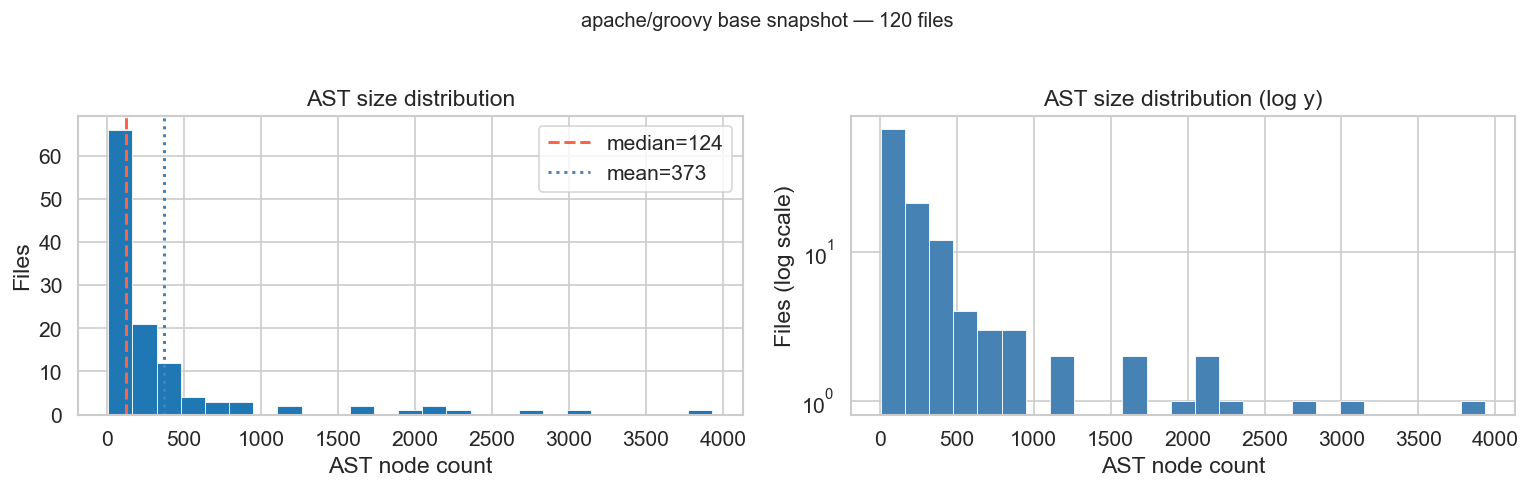

count     120.000000
mean      372.508333
std       647.679348
min         7.000000
25%        59.500000
50%       124.000000
75%       329.750000
max      3931.000000
Name: n_ast_nodes, dtype: float64

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- linear scale histogram ---
ax = axes[0]
ax.hist(df['n_ast_nodes'], bins=25, edgecolor='white', linewidth=0.5)
ax.axvline(df['n_ast_nodes'].median(), color='tomato',  lw=1.8, ls='--', label=f"median={df['n_ast_nodes'].median():.0f}")
ax.axvline(df['n_ast_nodes'].mean(),   color='steelblue', lw=1.8, ls=':',  label=f"mean={df['n_ast_nodes'].mean():.0f}")
ax.set_xlabel('AST node count')
ax.set_ylabel('Files')
ax.set_title('AST size distribution')
ax.legend()

# --- log-scale for tail ---
ax = axes[1]
ax.hist(df['n_ast_nodes'], bins=25, edgecolor='white', linewidth=0.5, color='steelblue')
ax.set_yscale('log')
ax.set_xlabel('AST node count')
ax.set_ylabel('Files (log scale)')
ax.set_title('AST size distribution (log y)')

plt.suptitle('apache/groovy base snapshot — 120 files', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

df['n_ast_nodes'].describe().rename('n_ast_nodes')

## 2  Depth distribution (max depth & avg depth per file)

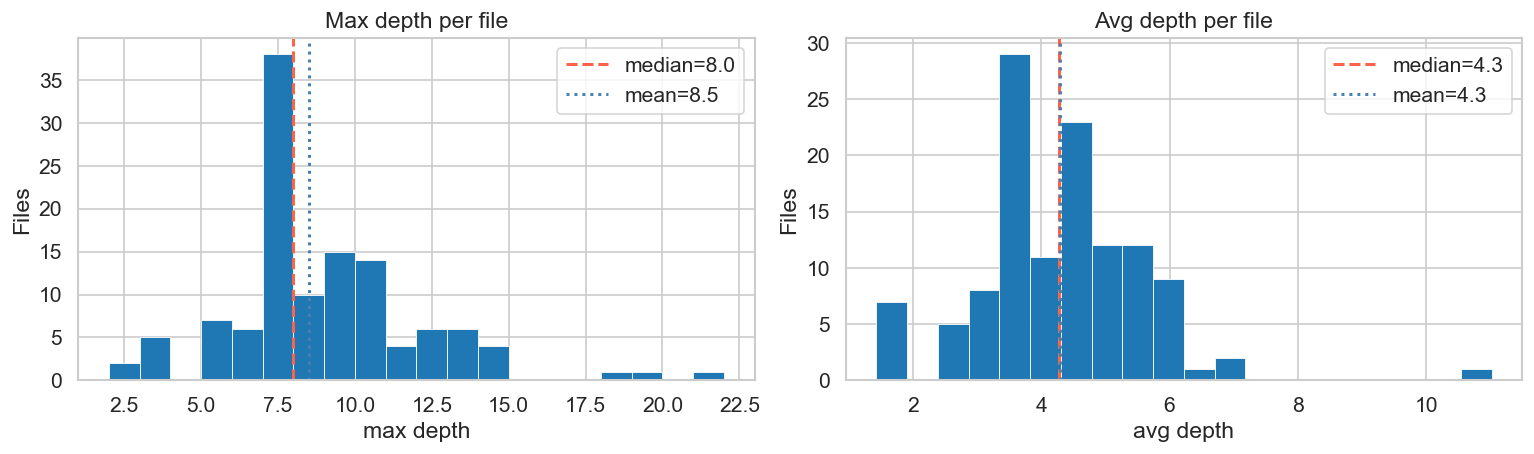

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, title in zip(
        axes,
        ['max_depth', 'avg_depth'],
        ['Max depth per file', 'Avg depth per file']):
    ax.hist(df[col], bins=20, edgecolor='white', linewidth=0.5)
    ax.axvline(df[col].median(), color='tomato',    lw=1.8, ls='--', label=f'median={df[col].median():.1f}')
    ax.axvline(df[col].mean(),   color='steelblue', lw=1.8, ls=':',  label=f'mean={df[col].mean():.1f}')
    ax.set_xlabel(col.replace('_', ' '))
    ax.set_ylabel('Files')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

## 3  AST group composition — per-file stacked bar

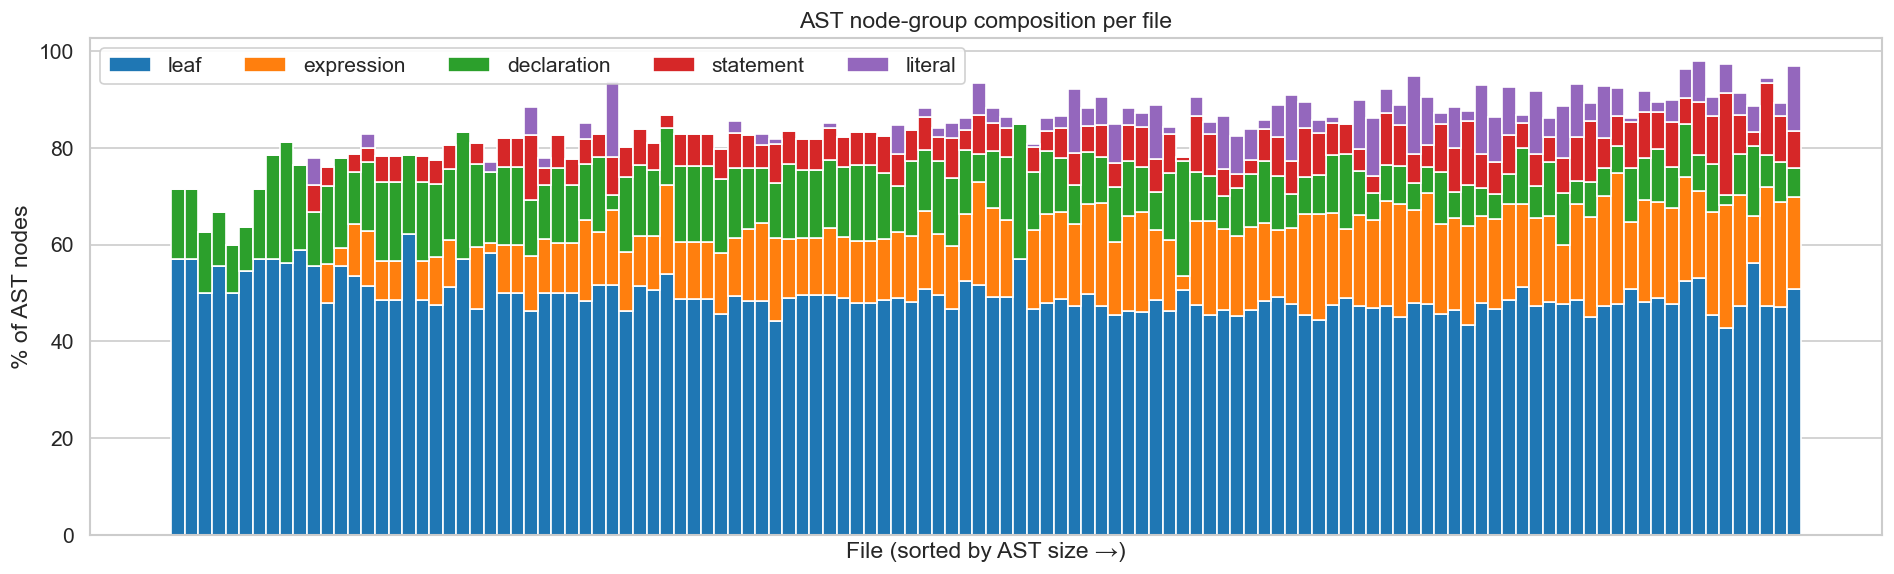

In [4]:
group_cols = ['pct_leaf', 'pct_expression', 'pct_declaration', 'pct_statement', 'pct_literal']
labels     = [c.replace('pct_', '') for c in group_cols]
colors     = sns.color_palette('tab10', len(group_cols))

# Sort files by n_ast_nodes for a readable ordering
plot_df = df.sort_values('n_ast_nodes').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 5))
bottom = np.zeros(len(plot_df))
for col, label, color in zip(group_cols, labels, colors):
    ax.bar(range(len(plot_df)), plot_df[col], bottom=bottom, label=label, color=color, width=1.0)
    bottom += plot_df[col].values

ax.set_xlabel('File (sorted by AST size →)')
ax.set_ylabel('% of AST nodes')
ax.set_title('AST node-group composition per file')
ax.set_xticks([])
ax.legend(loc='upper left', ncol=len(labels), framealpha=0.9)
plt.tight_layout()
plt.show()

## 4  Overall group composition — aggregate pie chart

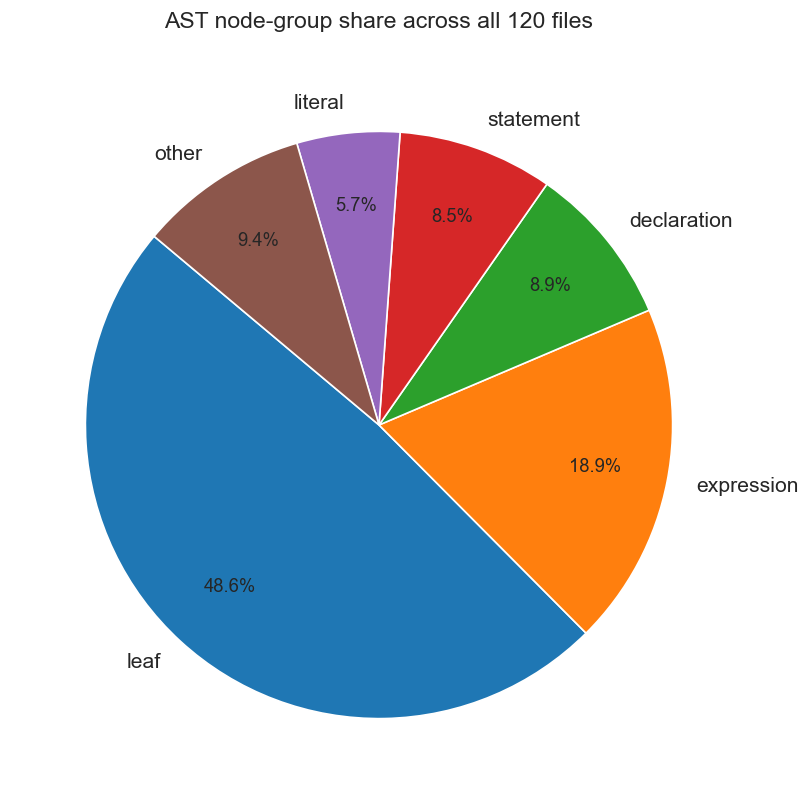

In [5]:
# Weighted aggregate: sum raw counts implied by pct * n_ast_nodes
group_sums = {label: (df[col] / 100 * df['n_ast_nodes']).sum()
              for col, label in zip(group_cols, labels)}
other = df['n_ast_nodes'].sum() - sum(group_sums.values())
if other > 0:
    group_sums['other'] = other

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    group_sums.values(),
    labels=group_sums.keys(),
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('tab10', len(group_sums)),
    pctdistance=0.75,
)
for at in autotexts:
    at.set_fontsize(11)
ax.set_title('AST node-group share across all 120 files', pad=18)
plt.tight_layout()
plt.show()

## 5  Entropy: type entropy vs group entropy

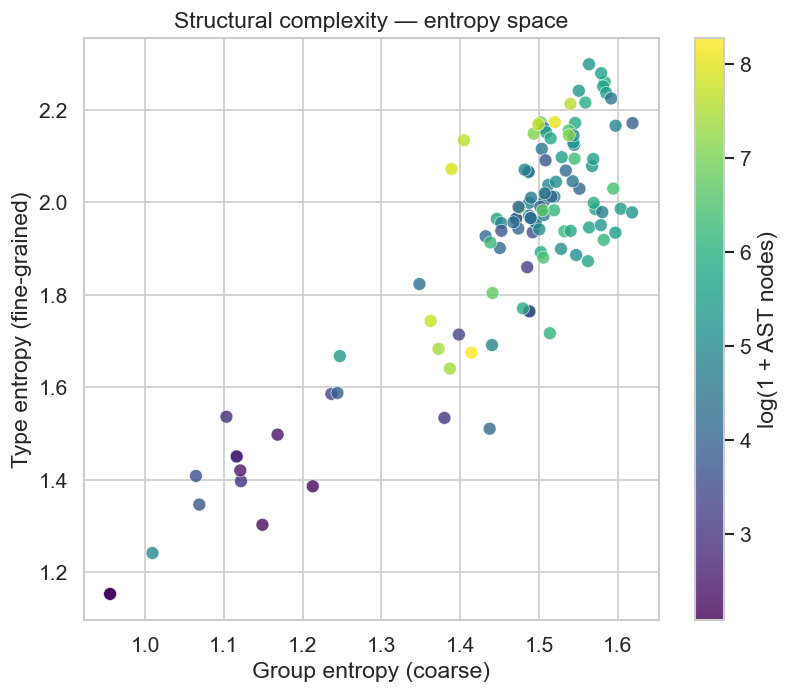

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(
    df['group_entropy'], df['type_entropy'],
    c=np.log1p(df['n_ast_nodes']), cmap='viridis',
    s=60, alpha=0.8, edgecolors='white', linewidths=0.4
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('log(1 + AST nodes)')
ax.set_xlabel('Group entropy (coarse)')
ax.set_ylabel('Type entropy (fine-grained)')
ax.set_title('Structural complexity — entropy space')
plt.tight_layout()
plt.show()

## 6  File size (bytes) vs AST node count

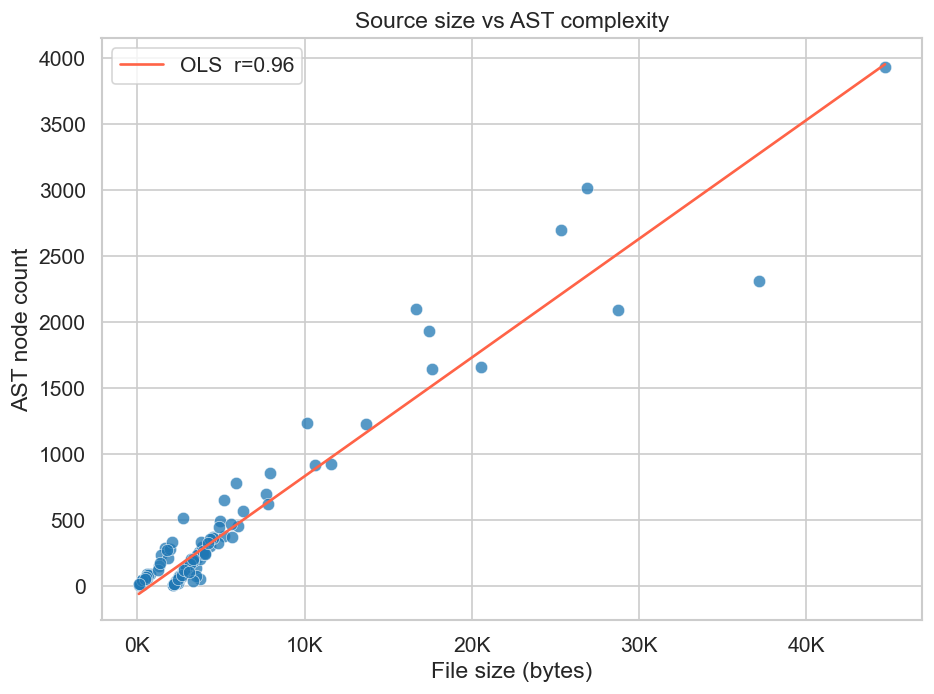

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df['file_size_bytes'], df['n_ast_nodes'],
           alpha=0.75, edgecolors='white', linewidths=0.4, s=55)

# regression line
m, b = np.polyfit(df['file_size_bytes'], df['n_ast_nodes'], 1)
x_line = np.linspace(df['file_size_bytes'].min(), df['file_size_bytes'].max(), 200)
ax.plot(x_line, m * x_line + b, color='tomato', lw=1.6, label=f'OLS  r={df[["file_size_bytes","n_ast_nodes"]].corr().iloc[0,1]:.2f}')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.set_xlabel('File size (bytes)')
ax.set_ylabel('AST node count')
ax.set_title('Source size vs AST complexity')
ax.legend()
plt.tight_layout()
plt.show()

## 7  Method / class / field counts — top 20 files by method count

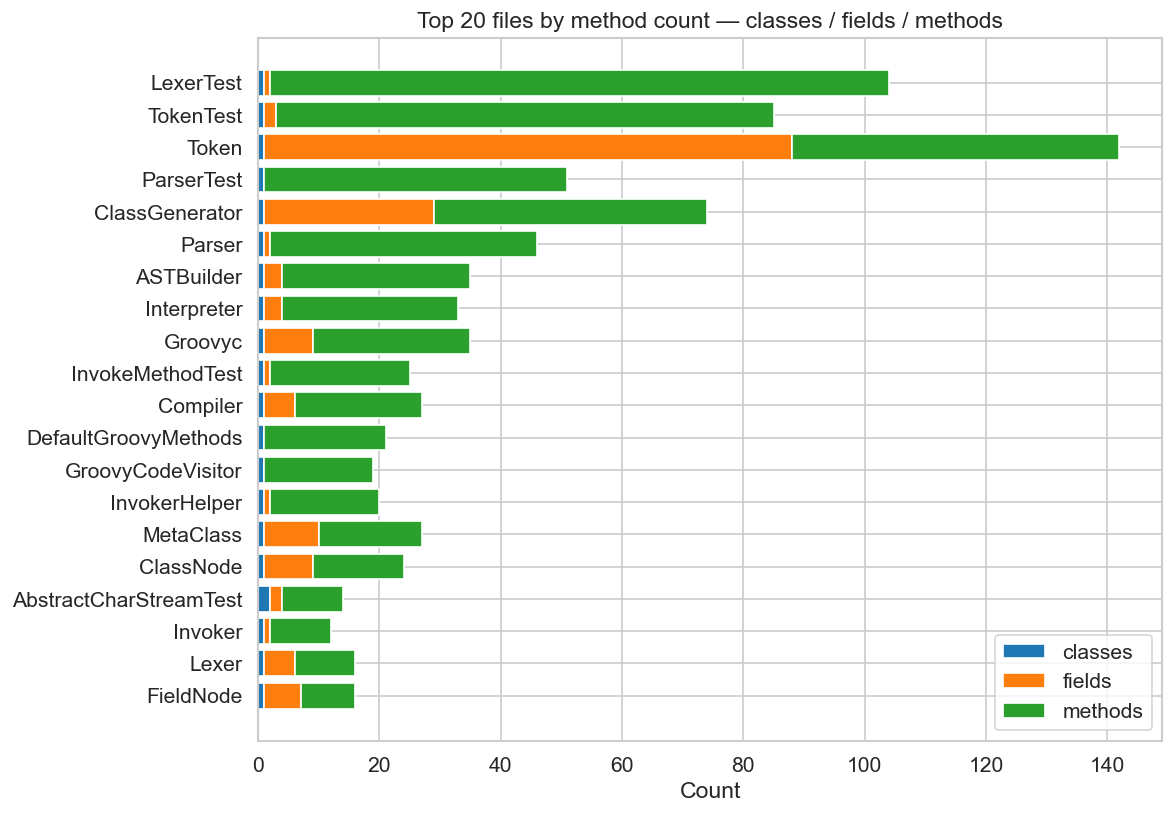

In [8]:
top20 = df.nlargest(20, 'n_methods')[['file', 'n_methods', 'n_fields', 'n_classes']].copy()
top20['short_name'] = top20['file'].apply(lambda p: Path(p).stem)
top20 = top20.set_index('short_name').sort_values('n_methods')

fig, ax = plt.subplots(figsize=(10, 7))
bottom = np.zeros(len(top20))
for col, label, color in zip(['n_classes','n_fields','n_methods'],
                              ['classes','fields','methods'],
                              sns.color_palette('tab10')):
    ax.barh(top20.index, top20[col], left=bottom, label=label)
    bottom += top20[col].values

ax.set_xlabel('Count')
ax.set_title('Top 20 files by method count — classes / fields / methods')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 8  Leaf ratio distribution

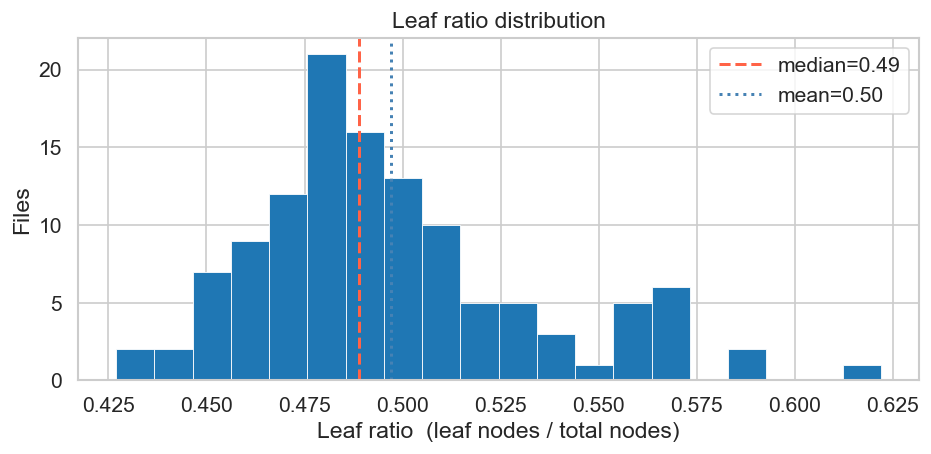

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['leaf_ratio'], bins=20, edgecolor='white', linewidth=0.5)
ax.axvline(df['leaf_ratio'].median(), color='tomato',    lw=1.8, ls='--', label=f"median={df['leaf_ratio'].median():.2f}")
ax.axvline(df['leaf_ratio'].mean(),   color='steelblue', lw=1.8, ls=':',  label=f"mean={df['leaf_ratio'].mean():.2f}")
ax.set_xlabel('Leaf ratio  (leaf nodes / total nodes)')
ax.set_ylabel('Files')
ax.set_title('Leaf ratio distribution')
ax.legend()
plt.tight_layout()
plt.show()

## 9  Neo4j graph overview — node labels & relationship types

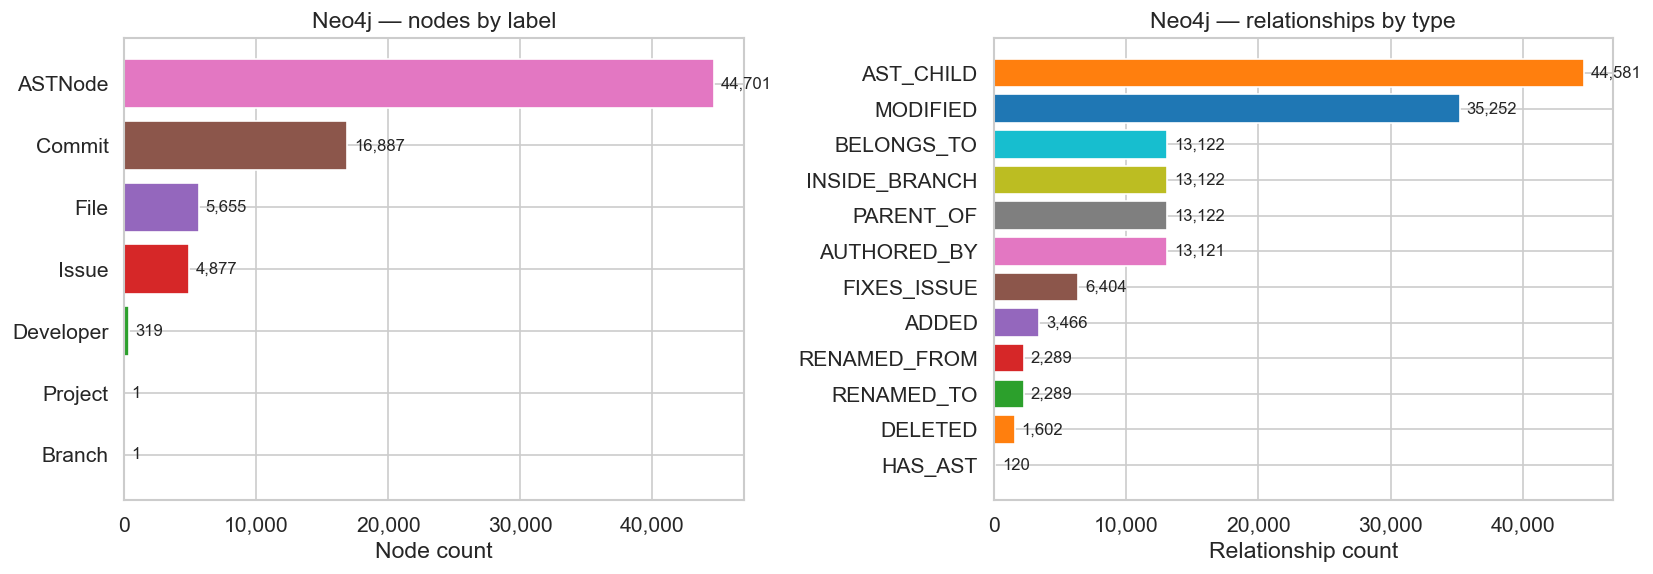


File nodes: 5,655  |  Files with AST: 120  |  Mismatches CSV↔Neo4j: 0


In [10]:
label_df = pd.DataFrame(summary['label_counts'])
rel_df   = pd.DataFrame(summary['relationship_counts'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# node labels
ax = axes[0]
bars = ax.barh(label_df['label'][::-1], label_df['total'][::-1],
               color=sns.color_palette('tab10', len(label_df)))
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=10)
ax.set_xlabel('Node count')
ax.set_title('Neo4j — nodes by label')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# relationship types
ax = axes[1]
bars = ax.barh(rel_df['rel'][::-1], rel_df['total'][::-1],
               color=sns.color_palette('tab10', len(rel_df)))
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=10)
ax.set_xlabel('Relationship count')
ax.set_title('Neo4j — relationships by type')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

print(f"\nFile nodes: {summary['file_node_count']:,}  |  "
      f"Files with AST: {summary['file_with_ast_count']}  |  "
      f"Mismatches CSV↔Neo4j: {summary['csv_vs_neo4j_mismatches']}")